# Praktikum 10: Explizite Runge-Kutta Verfahren höherer Ordnung

In Praktikum 9 haben Sie die Verfahren von Euler implementiert und für *ein* Anfangswertproblem das Fehlerverhalten in Abhängigkeit der Schrittweite untersucht. In diesem Praktikum erweitern Sie dies um drei explizite Verfahren. In Praktikum 11 tun Sie noch einmal dasselbe für zwei (oder drei) implizite Verfahren. Wenn Sie wollen, können Sie alle Verfahren in dasselbe Notebook schreiben.

### Aufgabe 1

Implementieren Sie die drei expliziten Verfahren  
1. Explizite Mittelpunktsregel (aka Runge)
2. Verfahren von Heun (aka explizite Trapezregel)
3. Klassisches Runge-Kutta vierter Ordnung (aka RK4)

die durch die folgenden Butcher-Tableaus definiert sind:

$$
    \begin{array}{c|ccc} 0 & \\ \frac12 & \frac12   \\\hline & 0 & 1 \end{array} \hspace{6em}
    \begin{array}{c|ccc} 0 & \\ 1 & 1   \\\hline & \frac12 & \frac12 \end{array} \hspace{6em}
     \begin{array}{c|ccccc} 0 & \\ \frac12 & \frac12 \\ \frac12 &  0 & \frac12 \\ 1 &  0 & 0 & 1    \\ \hline & \frac16 & \frac13 & \frac13 & \frac16
    \end{array}   
$$

und testen Sie diese an einem einfachen AWP, z.B.

$$
    y' = -y, \quad y(0) = 1
$$

### Aufgabe 2

Testen Sie die Verfahren an dem AWP -- **das ist dasselbe AWP wie in P9**

$$
    y' + \frac{x^2}{y} = 0, \qquad y(0) = -4, \qquad x \in [0, 2] 
$$

* Vergleichen Sie mit der exakten Lösung 

$$
    y(2) = - \frac{4}{3} \, \sqrt{6}, \qquad \textrm{bzw. } \, y(x) = -\sqrt{16 - \frac{2 \, x^3}{3}}
$$

an der Stelle $x = 2$.

* Erstellen Sie einen doppeltogarithmischen plot des Fehlers $$ e = |y_n - y(2)| $$ gegen die Schrittweite $h$ für verschiedene Schrittweiten, z.B.$$ h \in \left\{10^{-1}, 10^{-2}, 10^{-3}, 10^{-4} \right\}$$ Achten Sie darauf, die Endstelle $x_n = 2$ richtig zu treffen.
* Verifizieren Sie, dass die Fehler $e(h)$ etwa proportional zu $$e(h) \propto h^p$$ sind. Bestimmen Sie (aus dem Plot) den jeweiligen Wert von $p$ für alle drei Methoden. **Bemerkung 1** Für die beiden Verfahren von Euler ist $p = 1$, s. P9. **Bemerkung 2** Für RK4 kommen Sie mit den kleinsten Schrittweiten in den Bereich der (unvermeidbaren) Rundungsfehler.

### Aufgabe 3
Kleine Überlegungsaufgabe: Lohnt sich der Aufwand für ein Verfahren höherer Ordnung? Wie verhalten sich Rechenaufwand und Fehler zu einander? Sie können beispielsweise einfach den plot aus Aufgabe 2 in einen plot von Rechenaufwand vs. Fehler umwandeln, indem Sie die Genauigkeit nicht gegen die Schrittweite, sondern gegen den Rechenaufwand plotten. Der **Rechenaufwand** ist im wesentlichen die Anzahl der Funktionsaufrufe von $f(x, y)$. 





# Zusammenfassung der Verfahren:
## Explizit:
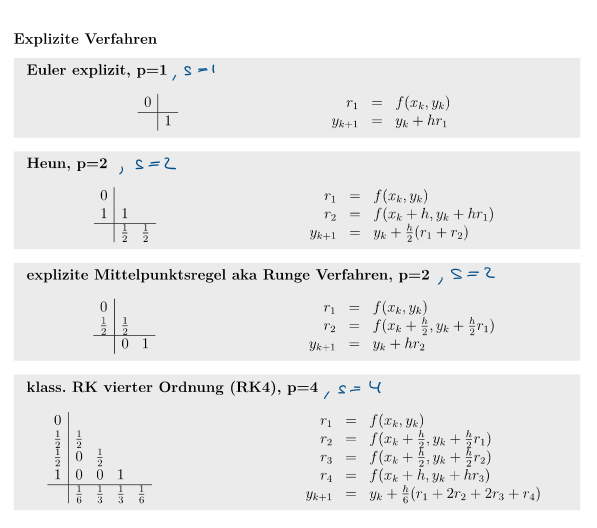
## Implizit:
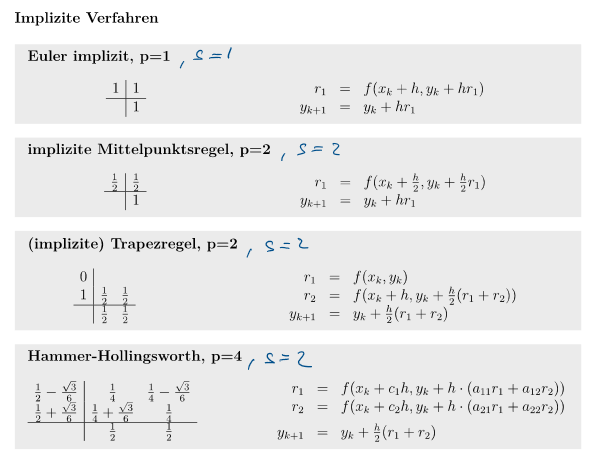

In [150]:
import numpy as np
import matplotlib.pyplot as plt

### <span style="color:gray"> Hilfsfunktion Newton-Verfahren </span>
Wird für P10 nicht gebraucht, nur falls Sie Euler implizit aus P9 übernehmen möchten, oder dann für P11

In [151]:
def newton(f, df, x, maxit = 100):
    for it in range(maxit):
        # 1. Den Korrekturwert berechnen
        delta = f(x) / df(x)      
        # 2. Den Wert verbessern (Update)
        x = x - delta
        # 3. Abbruchkriterium prüfen: Ist die Korrektur klein genug?
        if np.abs(delta) < 1e-10:
            break ## früher raus gehen
    return x

### <span style="color:gray"> Euler explizit </span> 
Optional aus P8, sonst löschen

In [152]:
def eulerExplizit(f, x0, y0, xn, h):
# initialisieren, der startpunkt aus den übergebenen startbedinung:
# TYP LISTE!
    x = [x0]
    y = [y0]

    n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite

    for i in range (n):
        x_alt = x[-1] ## letzer wert
        y_alt = y[-1] ## letzer wert
        x_neu = x_alt + h ## neuer x wert
        y_neu = y_alt + h * f(x_alt, y_alt) ## neuer y wert
        ##Werte an die Listen anhängen  ## APEND IST LISTE ANHäNGEN!
        x.append(x_neu)
        y.append(y_neu)
    return np.array(x), np.array(y) ## ergebnis zurückgeben

### <span style="color:gray"> Euler implizit </span>
Optional aus P9, sonst löschen

In [153]:
def eulerImplizit(f, df, x0, y0, xn, h):
## viel kopiert aus Aufgabe 1:
    # initialisieren, der startpunkt aus den übergebenen startbedinung:
    # TYP LISTE!
    x = [x0]
    y = [y0]
    n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite
    for i in range (n):
        ## KOPIERT AUS BEISPIEL!
        x.append(x[-1] + h)
        g  = lambda s: y[-1] + h * f(x[-1], s) - s
        dg = lambda s: h * df(x[-1], s) - 1
        yn = newton(g, dg, y[-1] + h/2 * f(x[-1], y[-1]))
        y.append( yn )
    return np.array(x), np.array(y)

### explizite Mittelpunktsregel (aka Verfahren von Runge)

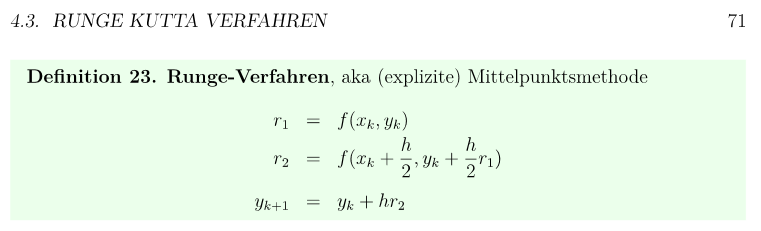

In [154]:
def Mittelpunktsregel(f, x0, y0, h, xn):
    x = [x0]
    y = [y0]
    
    # Anzahl der Schritte berechnen
    n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite
    
    # init temp
    xi = x0
    yi = y0

    for i in range(n):
        # 1. Steigungen berechnen (basierend auf dem AKTUELLEN Punkt)
        r1 = f(xi, yi)
        r2 = f(xi + h/2, yi + (h/2) * r1)
        
        # 2. Den nächsten Punkt berechnen
        yi = yi + h * r2  # yi wird für den nächsten Durchlauf aktualisiert
        xi = xi + h       # xi wird für den nächsten Durchlauf aktualisiert
        
        # in liste anhängen
        x.append(xi)
        y.append(yi)
        
    return np.array(x), np.array(y)

### explizite Trapezregel (aka Verfahren von Heun)

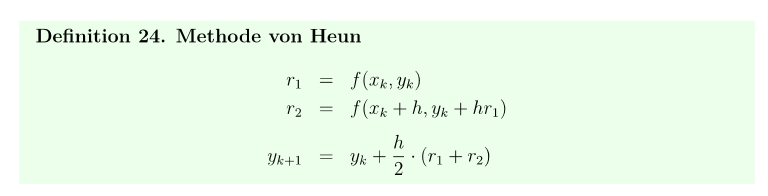

In [155]:
# %% Heun
def Heun(f, x0, y0, h, xn):

  x = [x0]
  y = [y0]

    # init temp
  xi = x0
  yi = y0

# Anzahl der Schritte berechnen
  n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite    

  for i in range(n):
    # 1. Steigung am Startpunkt
    r1 = f(xi, yi)
      
    # 2. Steigung am geschätzten Ende (Prädiktor)
    r2 = f(xi + h, yi + h * r1)
        
        # 3. Update-Schritt (Korrektor)
    yi = yi + (h / 2) * (r1 + r2)
    xi = xi + h
        
        # in liste anhängen
    x.append(xi)
    y.append(yi)
        
        
  return np.array(x), np.array(y)

### <span style="color:gray"> Implizite Mittelpunktsregel) </span>
Die implizite Mittelpunktsregel und die implizite Trapezregel implementieren Sie in Praktikum 11. **Für SW10 können Sie diese zwei Blöcke ignorieren**

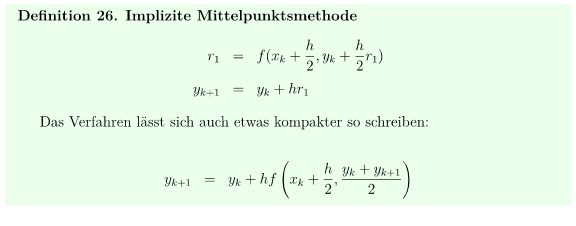

In [156]:
# %% Mittelpunktsregel  implizit
# kopiert aus beispiel skript
def Mittelpunktsregel_Impl(f, x0, y0, h, xn, df):

  x = [x0]
  y = [y0]
  # init temp
  xi = x0
  yi = y0
# Anzahl der Schritte berechnen
  n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite    

  
  for i in range (n):
        x_mid = x[-1] + h / 2
        r1 = f(x[-1], y[-1])
        ## KOPIERT AUS Newton implizit, aber andere g und dg!
        x.append(x[-1] + h)
        g  = lambda s: f(x_mid, y[-1] + h/2 * s) - s 
        #dg = lambda s: h/2 * df(x_mid, y[-1] + h/2 * s)
        dg = lambda s: h/2 * df(x[-1] + h, s) - 1
        r2 = newton(g, dg, y[-1] + h/2 * f(x[-1], y[-1]))
        yn = y[-1] + h/2 * (r1 + r2)
        y.append( yn )

  return np.array(x), np.array(y)

### <span style="color:gray"> Implizite Trapezregel) </span>


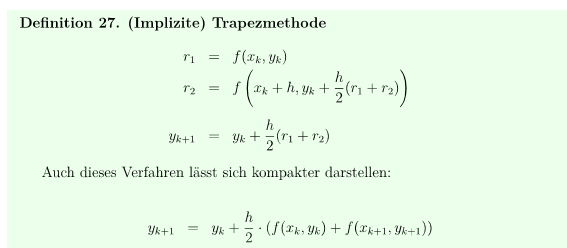

In [157]:
# %% Heun implizit
# kopiert aus beispiel skript
def Heun_Impl(f, x0, y0, h, xn, df):

  x = [x0]
  y = [y0]
  # init temp
  xi = x0
  yi = y0
# Anzahl der Schritte berechnen
  n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite    

  for i in range (n):
        r1 = f(x[-1], y[-1])
        ## KOPIERT AUS Newton implizit, aber andere g und dg!
        x.append(x[-1] + h)

        g  = lambda r2: f(x[-1], y[-1] + h/2 * r1 + h/2 * r2) - r2
        dg = lambda r2: h/2 * df(x[-1], y[-1] + h/2 * r1 + h/2 * r2) - 1
        r2 = newton(g, dg, y[-1] + h/2 * f(x[-1], y[-1]))

        yn = y[-1] + h/2 * (r1 + r2)
        y.append( yn )

  return np.array(x), np.array(y)

### Klassisches Runge-Kutta Verfahren vierter Ordnung (RK4)
**Dieser Block gehört hingegen zu P10...**

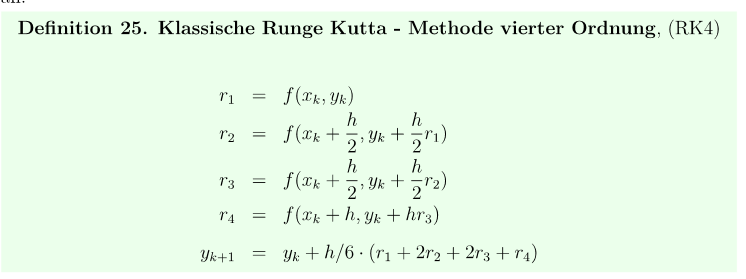

In [158]:
# %% RK4
# %% Heun
def RK4(f, x0, y0, h, xn):

    x = [x0]
    y = [y0]

        # init temp
    xi = x0
    yi = y0

# Anzahl der Schritte berechnen
    n = int((xn - x0) / h) ## anzahl schritte finden, ende minus anfang durch weite     

    for i in range(n):
        
        r1 = f(xi,yi)
        r2 = f(xi+(h/2), yi+(h/2)*r1)
        r3 = f(xi+h/2,yi+h/2*r2)
        r4 = f(xi+h,yi+h*r3)
    
        yi = yi + (h/6)*(r1+2*r2+2*r3+r4)
        xi = xi + h



        # in liste anhängen
        x.append(xi)
        y.append(yi)
        
    return np.array(x), np.array(y)


### Test...

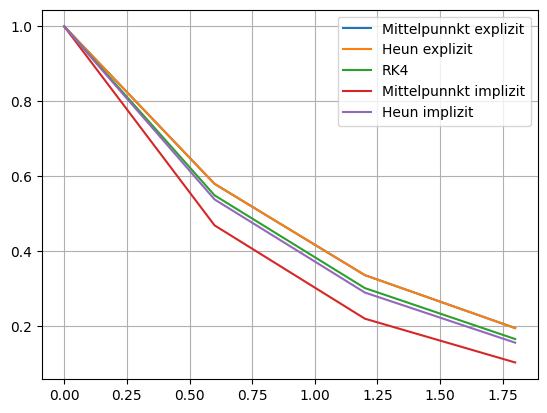

In [159]:
f = lambda x, y: -y  ### differentialgleichung
df = lambda x, y: -1  ### differentialgleichung abgeleitet

#Startwerte aus AWP
x0= 0
y0 =1

h = 0.6
xn = 2 #endpunkt


## RKs CALLEN WIE BEIPSIEL:
xm, ym = Mittelpunktsregel(f, x0, y0, h , xn)
xh, yh = Heun(f, x0, y0, h , xn)
xrk, yrk = RK4(f, x0, y0, h , xn)


xh_i, yh_i = Heun_Impl(f, x0, y0, h , xn, df)
xm_ii, ym_i = Mittelpunktsregel_Impl(f, x0, y0, h, xn, df)



### Lösungen plotten:
# numerische Lösungen
plt.plot(xm, ym, label="Mittelpunnkt explizit") # Mittelpunk punkte ausgeben
plt.plot(xh, yh, label="Heun explizit") # Heun punkte ausgeben
plt.plot(xrk, yrk, label="RK4") # RK4 punkte ausgeben

plt.plot(xm_ii, ym_i, label="Mittelpunnkt implizit") # Mittelpunk punkte ausgeben
plt.plot(xh_i, yh_i, label="Heun implizit") # Heun punkte ausgeben

plt.legend()
plt.grid()

### Vergleich der Fehlerordnung der Verfahren 

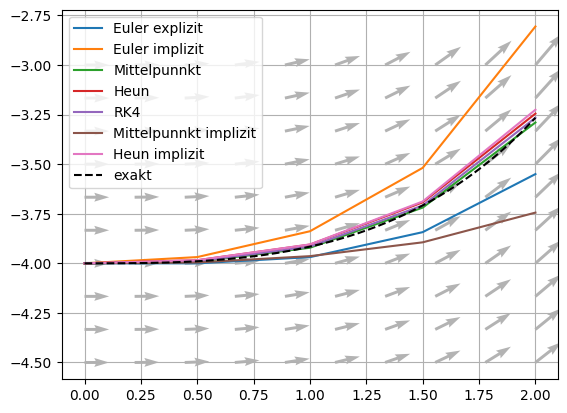

In [160]:
f = lambda x, y: - x**2 / y ## gegeben

## gefundene ableitung:
df = lambda x, y: x**2 / y**2
yexact = lambda x: -np.sqrt(16 - (2/3) * x**3) ## exakte Lösung der DGL, mit trennung variablen. minus wurzel wegen anfangsedingung

# Startwerte aus aufgabenstellung
y0 = -4  
x0 = 0 
h = 0.5
xn = 2 ## wie oben

## EULER CALLEN WIE BEIPSIEL:
xe, ye = eulerExplizit(f, x0, y0, xn , h)
xi, yi = eulerImplizit(f, df, x0, y0, xn , h)

## RKs CALLEN WIE BEIPSIEL:
xm, ym = Mittelpunktsregel(f, x0, y0, h , xn)
xh, yh = Heun(f, x0, y0, h , xn)
xrk, yrk = RK4(f, x0, y0, h , xn)

# noch die Impliziten
xm_i, ym_i = Mittelpunktsregel_Impl(f, x0, y0, h , xn, df)
xh_i, yh_i = Heun_Impl(f, x0, y0, h , xn, df)



### Lösungen plotten:
# numerische Lösungen
plt.plot(xe, ye, label="Euler explizit") # explizite punkte ausgeben
plt.plot(xi, yi, label="Euler implizit") # implizite punkte ausgeben

### Lösungen plotten:
# numerische Lösungen
plt.plot(xm, ym, label="Mittelpunnkt") # Mittelpunk punkte ausgeben
plt.plot(xh, yh, label="Heun") # Heun punkte ausgeben
plt.plot(xrk, yrk, label="RK4") # RK4 punkte ausgeben

plt.plot(xm_i, ym_i, label="Mittelpunnkt implizit") # Mittelpunk punkte ausgeben
plt.plot(xh_i, yh_i, label="Heun implizit") # Heun punkte ausgeben

# exakte Lösung
x_plot = np.linspace(0, 2, 200) ## 200 punkte erstellen 
plt.plot(x_plot, yexact(x_plot), 'k--', label="exakt") ## und dann ausgeben

plt.legend()
plt.grid()

# gegeben:
xq = np.linspace(0, 2, 10)        # x-Achse für Vektorfeld
yq = np.linspace(-4.5, -3, 10)    # y-Achse für Vektorfeld
X, Y = np.meshgrid(xq, yq)        # Raster aus den Achsen erzeugen
u = lambda x, y: np.ones_like(x) # x' = 1
v = lambda x, y: f(x, y)         # y' = f(x, y)
# die Option angles = "xy" sorgt dafür, dass die Steigung an die Skalierung der Achsen angepasst wird
plt.quiver(X, Y, u(X, Y), v(X, Y), angles = "xy", color = [.7,.7,.7])

h =  0.1
h =  0.01
h =  0.001
h =  0.0001
h =  1e-05


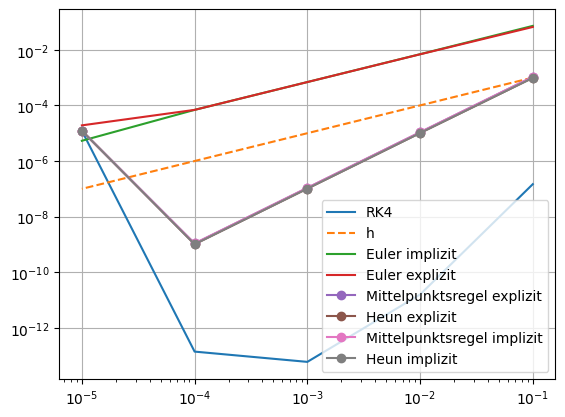

In [161]:
## GEGEBEN, ABER & WErte hs = np.logspace(-1, -5, 6) # noch viel kleinere Schrittweiten h ergeben evtl. lange Rechenzeiten...
# SO IST ES EXAKT WIE IM BILD VERLANGT:
hs = np.logspace(-1, -5, 5)


#FehlerArray
errRK = []
errI = []
errE = [] 
errM = []
errH = []
errM_I = []
errH_I = []

#KostenArray
costE = []
costI = []
costM = []
costH = []
costR = []
costH_I = []
costM_I = []


for h in hs:
    print("h = ", h)
    N = int(np.round((xn - x0)/h))
    xrk, yrk = RK4(f, x0, y0, h, xn)
    errRK.append(abs(yrk[-1] - yexact(2)))
    ## eulers
    xi, yi = eulerImplizit(f, df, x0, y0, xn, h)
    errI.append(abs(yi[-1] - yexact(2)))
    xe, ye = eulerExplizit(f, x0, y0, xn, h) 
    err = abs(ye[-1] - yexact(2))  #exakte Lösung der DGL an der Stelle x=2: y(2) = 2 * e^(-4*2) = 2 * e^(-8)
    errE.append(err)
    #################
    xm, ym = Mittelpunktsregel(f, x0, y0, h, xn)
    xh, yh = Heun(f, x0, y0, h, xn)
    errM.append(abs(ym[-1] - yexact(xn)))
    errH.append(abs(yh[-1] - yexact(xn)))

    xm_i, ym_i = Mittelpunktsregel_Impl(f, x0, y0, h, xn, df)
    xh_i, yh_i = Heun_Impl(f, x0, y0, h, xn, df)
    errM_I.append(abs(ym[-1] - yexact(xn)))
    errH_I.append(abs(yh[-1] - yexact(xn)))
#####
    ##COSTS:
    costE.append(N * 1)
    costI.append(N * 1)
    costM.append(N * 2)
    costH.append(N * 2)
    costR.append(N * 4)

    costM_I.append(N * 2)
    costH_I.append(N * 2)

plt.figure()
plt.loglog(hs, np.abs(errRK), label = "RK4")
plt.loglog(hs, 1e-2*hs, '--', label = "h")
plt.loglog(hs, np.abs(errI), label = "Euler implizit")
plt.loglog(hs, np.abs(errE), label = "Euler explizit")
plt.loglog(hs, errM, 'o-', label='Mittelpunktsregel explizit')
plt.loglog(hs, errH, 'o-', label='Heun explizit')

plt.loglog(hs, errM_I, 'o-', label='Mittelpunktsregel implizit')
plt.loglog(hs, errH_I, 'o-', label='Heun implizit')

plt.legend()
plt.grid()

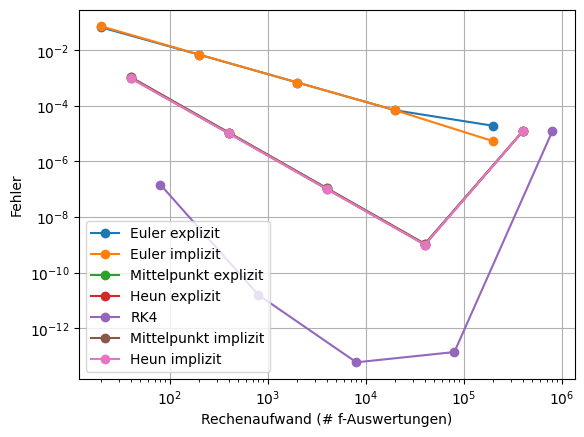

In [162]:
plt.figure()
 
plt.loglog(costE, errE, 'o-', label='Euler explizit')
plt.loglog(costI, errI, 'o-', label='Euler implizit')
plt.loglog(costM, errM, 'o-', label='Mittelpunkt explizit')
plt.loglog(costH, errH, 'o-', label='Heun explizit')
plt.loglog(costR, errRK, 'o-', label='RK4')

plt.loglog(costM_I, errM_I, 'o-', label='Mittelpunkt implizit')
plt.loglog(costH_I, errH_I, 'o-', label='Heun implizit')
 
plt.xlabel('Rechenaufwand (# f-Auswertungen)')
plt.ylabel('Fehler')
plt.legend()
plt.grid(True)
plt.show()